PROBLEMA 1: DINÁMICA CUÁNTICA Y COMPLEJIDAD COMPUTACIONAL


a) Determinar la dimensión del espacio de Hilbert en función de N

Para determinar la dimensión del sistema, analizamos los grados de libertad de cada partícula:

* Sabemos que cada espín $1/2$ tiene una base de 2 estados posibles: $|\uparrow\rangle$ (arriba) y $|\downarrow\rangle$ (abajo). Por lo tanto, la dimensión de cada subespacio es $d_i = 2$.
* En este caso, al tener una cadena de $N$ espines, el espacio de Hilbert total ($\mathcal{H}$) se define mediante el producto tensorial de los espacios individuales:
  $$\mathcal{H} = \mathcal{H}_1 \otimes \mathcal{H}_2 \otimes \dots \otimes \mathcal{H}_N$$

* Dado lo anterior, la dimensión total es el producto de las dimensiones de cada subespacio. Al tener $N$ factores de 2, la dimensión crece de forma exponencial, resultando para este caso, $$d = 2^N$$



In [2]:
import numpy as np
from scipy.linalg import expm
import time
import matplotlib.pyplot as plt

# Matrices de Pauli
sx = np.array([[0,1],[1,0]])
sz = np.array([[1,0],[0,-1]])
I = np.eye(2)
#b) Construir el Hamiltoniano en Python (N, J, B) con h_barra = 1
def operador_sigma(n_spins, j, sigma_type):
    op_list = [I] * n_spins
    op_list[j] = sigma_type
    
    res = op_list[0]
    for i in range(1, n_spins):
        res = np.kron(res, op_list[i])
    return res
def Hamiltoniano(N, J, B):
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)
    
    # Término de interacción (J) entre espines vecinos
    for i in range(N - 1):
        sxi = operador_sigma(N, i, sx)
        sxi_1 = operador_sigma(N, i + 1, sx)
        H += J * (sxi @ sxi_1)
        
    # Término de campo transversal (B)
    for i in range(N):
        szi = operador_sigma(N, i, sz)
        H += B * szi
        
    return H



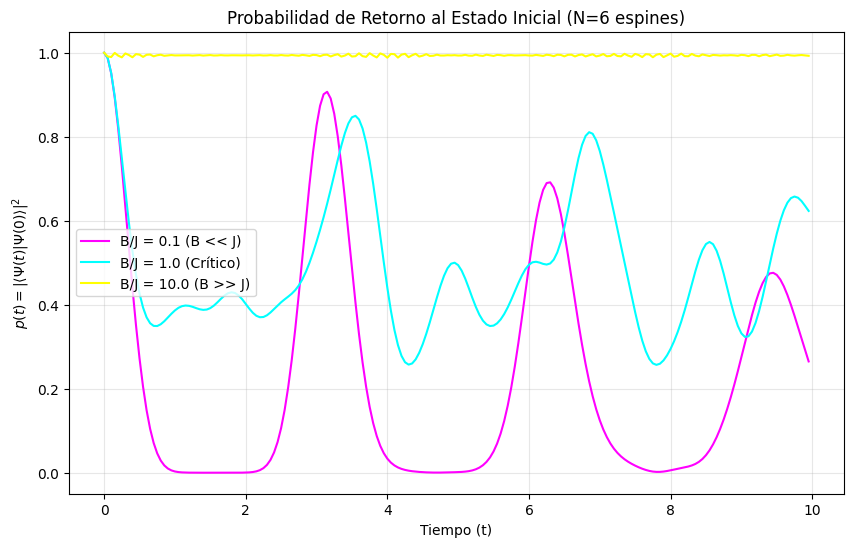

In [11]:
#c) Utilizando scipy.linalg.expm o diagonalización, calcule el operador de evolución U y simule la evolución de un estado inicial |Ψ(0)⟩ = |↓ · · · ↓⟩ = |↓⟩⊗· · ·⊗|↓⟩ durante varios
# pasos temporales. Para ello, defina un arreglo de tiempo discreto tal que tk+1−tk = ∆t. 
# Grafique la probabilidad de retornar al estado inicial p(t) = |⟨Ψ(t)|Ψ(0)⟩|2 para los casos B/J ≪ 1, B/J = 1 y B/J ≫ 1.
def evolucion_proba_pdt(N, J, B, dt, pasos_tot):
    H = Hamiltoniano(N, J, B)
    # Operador de evolución U con h_barra = 1 
    U = expm(-1j * H * dt)
    down = np.array([0, 1], dtype=complex)
    psi_0 = down.copy()
    for _ in range(N - 1):
        psi_0 = np.kron(psi_0, down)
    
    psi_t = psi_0.copy()
    p_return = []
    
    for _ in range(pasos_tot):
        # p(t) = |<Psi(t)|Psi(0)>|^2 
        overlap = np.vdot(psi_t, psi_0)
        p_return.append(np.abs(overlap)**2)
        # Evolucionar un paso temporal
        psi_t = U @ psi_t
        
    return p_return

# Datos para simular
N = 6           # Número de espines
dt = 0.05       # Paso temporal
pasos = 200     
t_axis = np.arange(pasos) * dt
# Casos: B/J << 1, B/J = 1, B/J >> 1 
casos_simulación = {
    "B/J = 0.1 (B << J)": (1.0, 0.1),
    "B/J = 1.0 (Crítico)": (1.0, 1.0),
    "B/J = 10.0 (B >> J)": (1.0, 10.0)
}

# Gráfico
plt.figure(figsize=(10, 6))
colores = ['fuchsia', 'cyan', 'yellow']
for (label, (J, B)), color in zip(casos_simulación.items(), colores):
    prob = evolucion_proba_pdt(N, J, B, dt, pasos)
    plt.plot(t_axis, prob, label=label, color=color)


plt.title(f"Probabilidad de Retorno al Estado Inicial (N={N} espines)")
plt.xlabel("Tiempo (t)")
plt.ylabel(r"$p(t) = |\langle\Psi(t)|\Psi(0)\rangle|^2$")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Iniciando mediciones de tiempo...
N     | Tiempo promedio (s) 
------------------------------
4     | 0.002605            
5     | 0.003759            
6     | 0.008070            
7     | 0.025159            
8     | 0.093415            


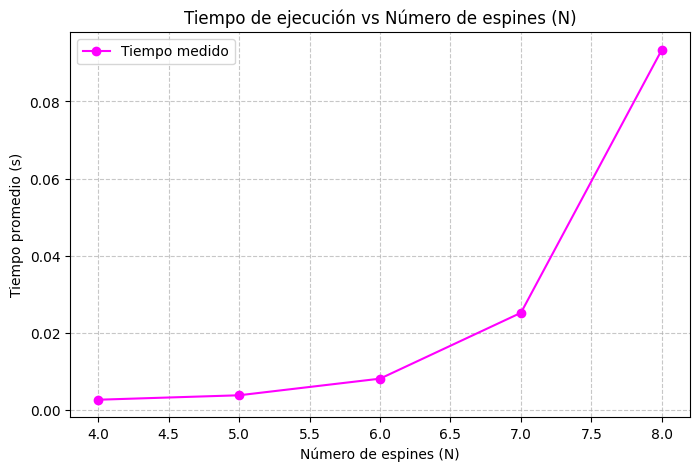

In [ ]:
#(d) Mida el tiempo de cálculo necesario para construir y diagonalizar el Hamiltoniano para distintos tamaños del sistema (N = 4, 5, 6, 7, 8).
def diago_hamiltoniano(N, J, B):
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)
    for i in range(N - 1):
        H += J * (operador_sigma(N, i, sx) @ operador_sigma(N, i + 1, sx))
    for i in range(N):
        H += B * operador_sigma(N, i, sz)
    
    # Diagonalización
    # Usamos np.linalg.eigh porque H es hermitiano
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    return eigenvalues

# Medición del tiempo para distintos N
N_values = [4, 5, 6, 7, 8] 
J, B = 1.0, 1.0
num_realizaciones = 5 
tiempos_promedio = []

print("Iniciando mediciones de tiempo...")
print(f"{'N':<5} | {'Tiempo promedio (s)':<20}")
print("-" * 30)

for N in N_values:
    tiempos_n = []
    for _ in range(num_realizaciones):
        t_inicio = time.time()
        
        # Ejecutar
        diago_hamiltoniano(N, J, B)
        
        t_fin = time.time()
        tiempos_n.append(t_fin - t_inicio)
    
    promedio = np.mean(tiempos_n)
    tiempos_promedio.append(promedio)
    print(f"{N:<5} | {promedio:<20.6f}")
# (e) Grafique el tiempo de ejecución en función de N (recuerde promediar varias realizaciones).
plt.figure(figsize=(8, 5))
plt.plot(N_values, tiempos_promedio, 'o-', color='fuchsia', label='Tiempo medido')

plt.title("Tiempo de ejecución vs Número de espines (N)")
plt.xlabel("Número de espines (N)")
plt.ylabel("Tiempo promedio (s)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()


(f) Utilizando los tiempos obtenidos, estime cuánto demoraría la simulación para N = 20, N = 50 y N = 100 espines. No simule estos casos, ya que por construcción no tendrá la memoria suficiente.
Utilizando los datos de tiempo obtenidos para $N=4$ hasta $N=8$, se observa que el tiempo de ejecución escala de forma exponencial siguiendo la relación $T(N) \propto 2^{3N}$ (debido a la complejidad $O(D^3)$ de la diagonalización, donde $Dim = 2^N$). Realizando una extrapolación basada en la capacidad de cómputo actual:

* Para $N=20$: El tiempo estimado ya alcanza el orden de los días o semanas de procesamiento continuo.
* Para $N=50$: El tiempo estimado es de aproximadamente $10^{30}$ años, una cifra que excede cualquier capacidad humana actual.
* Para $N=100$: La simulación es computacionalmente intratable. No solo por el tiempo, sino porque la memoria necesaria para almacenar una matriz de $2^{100} \times 2^{100}$ supera los átomos del universo observable.

(g) Compare su estimación en (f) con la edad del universo (≈ 4,3 × 1017 segundos).
La edad estimada del universo es de aproximadamente $4,3 \times 10^{17}$ segundos. Al comparar nuestras estimaciones del punto anterior:
Se concluye que simular un sistema de apenas $N=50$ o $N=100$ espines mediante métodos de fuerza bruta (diagonalización exacta) requeriría un tiempo de ejecución muchas órdenes de magnitud superior a la edad del universo.Esto demuestra que, incluso con supercomputadores, la simulación clásica de sistemas cuánticos de muchos cuerpos es inviable bajo este enfoque.

(h) Discuta por qué este crecimiento exponencial del espacio de Hilbert representa uno de los principales desafíos para la simulación clásica de sistemas cuánticos de muchos cuerpos.
El crecimiento exponencial del espacio de Hilbert ($2^N$) es uno de los mayores desafíos de la física moderna por las siguientes razones:
1.Intratabilidad de la Simulación Clásica: Añadir un solo componente al sistema (un espín más) duplica el tamaño del vector de estado y cuadruplica el tamaño de la matriz del Hamiltoniano, volviendo el sistema rápidamente "pesado" para cualquier hardware clásico.
2.Límite de Almacenamiento: La memoria RAM necesaria para representar fielmente el estado de sistemas con $N > 50$ no existe en la Tierra actualmente.
3.Necesidad de Nuevos Paradigmas: Este desafío justifica la búsqueda de alternativas como la (que procesa información en un espacio de Hilbert de forma nativa) o algoritmos de aproximación como redes de Tensores y Monte Carlo Cuántico.